KB 09October2025

Try to use Psytrack 

Link: https://github.com/nicholas-roy/psytrack/blob/master/psytrack/examples/ExampleNotebook.ipynb

Link2: https://github.com/davcrom/ibl_neuromodulators/blob/main/behaviour/PsyTrack_defpip.ipynb


In [4]:
""" 1. IMPORTS """ 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from functions import *
import sys
sys.path.insert(0, "/home/kceniabougrova/Documents/GitHub/ibl-photometry/src")


df_good_BCW = pd.read_excel("/home/kceniabougrova/Downloads/good_sessions_outputs/df_good_BCW.xlsx")

i = 4
row = df_good_BCW.iloc[i]

# =========================================================
# Extract metadata
# =========================================================
subject = row['subject']
date = str(row['date'])[:10]
region = row['region']
fiber = row['fiber']
eid = row['eid']

print(f"📦 Session {i} — {subject} | {date} | {region} | {fiber} | {eid}")

# =========================================================
# Locate corresponding files in your folder
# =========================================================
BASE_DIR = "/home/kceniabougrova/Downloads/good_sessions_outputs/"

df_trials_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_trials_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

df_nph_file = [
    f for f in os.listdir(BASE_DIR)
    if f.startswith("df_nph_")
    and subject in f
    and date in f
    and region in f
    and eid in f
]

if not df_trials_file or not df_nph_file:
    print("⚠️ Missing one or both files in folder!")
else:
    df_trials_path = os.path.join(BASE_DIR, df_trials_file[0])
    df_nph_path = os.path.join(BASE_DIR, df_nph_file[0])

    print(f"✅ Found df_trials -> {df_trials_path}")
    print(f"✅ Found df_nph -> {df_nph_path}")

    # Load them
    df_trials = pd.read_csv(df_trials_path)
    df_nph = pd.read_csv(df_nph_path)

    print(f"df_trials shape: {df_trials.shape}")
    print(f"df_nph shape: {df_nph.shape}")

📦 Session 4 — ZFM-03059 | 2021-10-11 | Region1G | probe01 | 8e90ac76-47c7-441b-b370-204a8002abd8
✅ Found df_trials -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_trials_7_ZFM-03059_2021-10-11_Region1G_8e90ac76-47c7-441b-b370-204a8002abd8.csv
✅ Found df_nph -> /home/kceniabougrova/Downloads/good_sessions_outputs/df_nph_7_ZFM-03059_2021-10-11_Region1G_8e90ac76-47c7-441b-b370-204a8002abd8.csv
df_trials shape: (633, 29)
df_nph shape: (48893, 4)


In [44]:
D = df_trials.copy()
D['y'] = D['choice'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D = D[D['choice'] != 0]                       # remove trials where choice == 0

print("The keys of the dict for this example animal:\n   ", list(D.keys()))
print("The shape of y:   ", D['y'].shape)
print("The number of trials:   N =", D['y'].shape[0])
print("The unique entries of y:   ", np.unique(D['y']))



The keys of the dict for this example animal:
    ['stimOffTrigger_times', 'stimOff_times', 'allContrasts', 'allSContrasts', 'goCueTrigger_times', 'included', 'quiescencePeriod', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume', 'probabilityLeft', 'firstMovement_times', 'intervals_0', 'intervals_1', 'subject', 'date', 'eid', 'reactionTime', 'responseTime', 'quiescenceTime', 'trialTime', 'trialNumber', 'y']
The shape of y:    (676,)
The number of trials:   N = 676
The unique entries of y:    [1. 2.]


In [5]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 140

import psytrack as psy

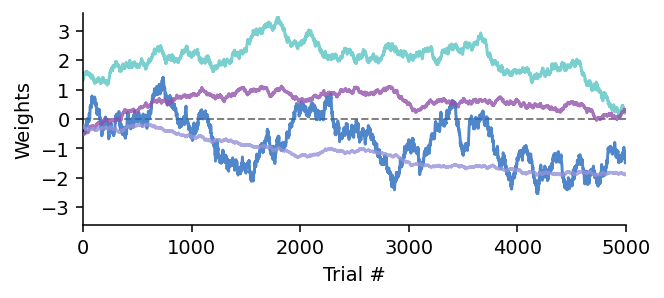

In [6]:
seed = 31
num_weights = 4
num_trials = 5000
hyper = {'sigma'   : 2**np.array([-4.0,-5.0,-6.0,-7.0]),
         'sigInit' : 2**np.array([ 0.0, 0.0, 0.0, 0.0])}

# Simulate
simData = psy.generateSim(K=num_weights, N=num_trials, hyper=hyper,
                          boundary=6.0, iterations=1, seed=seed, savePath=None)

# Plot
psy.plot_weights(simData['W'].T);
plt.ylim(-3.6,3.6);

In [20]:
hyper[0].shape

KeyError: 0

In [7]:
rec = psy.recoverSim(simData)

In [8]:
rec

{'iteration': 0,
 'N': 5000,
 'K': 4,
 'input': {'sigInit': array([1., 1., 1., 1.]),
  'sigDay': None,
  'sigma': array([0.0625   , 0.03125  , 0.015625 , 0.0078125]),
  'dayLength': None,
  'seed': 31,
  'W': array([[-0.4343693 ,  1.34700479, -0.49779972, -0.2405024 ],
         [-0.43356056,  1.32084552, -0.49964051, -0.25749655],
         [-0.47947976,  1.34969436, -0.51976486, -0.25537572],
         ...,
         [-1.48016105,  0.33025206,  0.27561389, -1.8873101 ],
         [-1.42635657,  0.29754755,  0.28747175, -1.90199806],
         [-1.49545299,  0.2715588 ,  0.27901971, -1.90278552]]),
  'X': array([[-1.53838712,  0.42103903,  0.41645744, -0.68211591],
         [ 0.10428459, -1.51795415, -0.57449161, -0.05326662],
         [ 0.64070616,  2.27887192,  0.72229007, -0.66272997],
         ...,
         [ 0.26584933,  2.0332635 , -0.7496208 ,  0.47398381],
         [-0.17065255,  0.06548138,  0.50212868,  1.55632706],
         [ 1.20698087, -0.53682278, -0.60912088, -0.17290518]]),


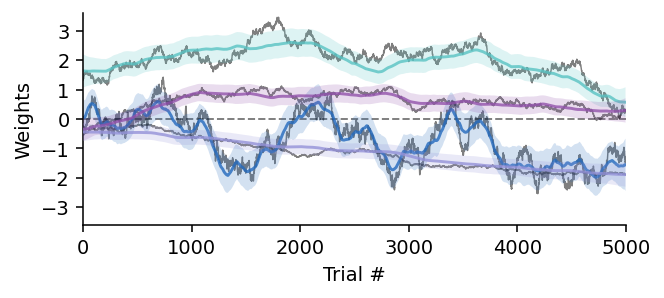

In [9]:
psy.plot_weights(rec['wMode'], errorbar=rec["hess_info"]["W_std"])
plt.plot(simData['W'], c="k", ls="-", alpha=0.5, lw=0.75, zorder=0)
plt.ylim(-3.6,3.6);


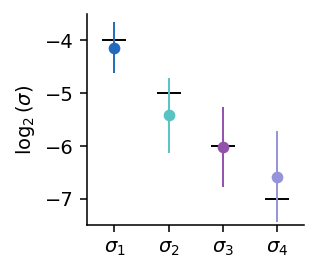

In [10]:
true_sigma = np.log2(rec['input']['sigma'])
avg_sigma = np.log2(rec['hyp']['sigma'])
err_sigma = rec['hess_info']['hyp_std']

plt.figure(figsize=(2,2))
colors = np.unique(list(psy.COLORS.values()))
for i in range(num_weights):
    plt.plot(i, true_sigma[i], color="black", marker="_", markersize=12, zorder=0)
    plt.errorbar([i], avg_sigma[i], yerr=2*err_sigma[i], color=colors[i], lw=1, marker='o', markersize=5)

plt.xticks([0,1,2,3]); plt.yticks(np.arange(-8,-2))
plt.gca().set_xticklabels([r"$\sigma_1$", r"$\sigma_2$", r"$\sigma_3$", r"$\sigma_4$"])
plt.xlim(-0.5,3.5); plt.ylim(-7.5,-3.5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylabel(r"$\log_2(\sigma)$");

In [33]:
D = df_trials.copy()
D['y'] = D['choice'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D['feedbackType'] = D['feedbackType'].replace({-1: 1, 1: 2})   # map -1 → 1, 1 → 2
D = D[D['choice'] != 0] 
D

,quiescencePeriod,included,allContrasts,allSContrasts,stimOff_times,goCueTrigger_times,stimOffTrigger_times,stimOnTrigger_times,goCue_times,response_times,...,intervals_1,subject,date,eid,reactionTime,responseTime,quiescenceTime,trialTime,trialNumber,y
0,0.609936,True,1.000,-1.000,5.705700,3.977200,5.648200,3.877100,3.994400,4.648100,...,6.205702,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.304542,0.7710,3.8771,6.205702,1,2.0
1,0.408291,True,0.000,0.000,58.922500,7.457100,58.860100,7.397800,7.483800,57.860000,...,59.422502,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.881842,50.4622,0.4084,52.433102,2,1.0
2,0.632563,True,0.000,0.000,85.571400,61.971200,85.516900,61.917800,62.003900,84.516800,...,86.071402,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,7.061842,22.5990,1.7483,25.901902,3,1.0
4,0.532917,True,0.250,-0.250,153.804700,152.454600,153.743800,152.395100,152.486500,152.743700,...,154.304702,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.254542,0.3486,0.7386,2.648202,5,2.0
5,0.563320,True,0.250,-0.250,158.686199,157.236499,158.623899,157.190799,157.264099,157.623799,...,159.186202,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.245843,0.4330,2.1944,4.189803,6,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
626,0.554065,True,0.125,0.125,3053.802299,3049.502599,3053.742499,3049.444999,3049.535999,3051.742399,...,3054.302301,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,1.912643,2.2974,1.8329,6.690202,627,2.0
627,0.500032,True,1.000,1.000,3057.251199,3055.584899,3057.198999,3055.540799,3055.614799,3056.198899,...,3057.751201,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.261843,0.6581,0.5002,2.710602,628,1.0
628,0.656389,True,1.000,-1.000,3061.452098,3060.118598,3061.387798,3060.056198,3060.148398,3060.387698,...,3061.952101,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.201444,0.3315,1.5842,3.480103,629,2.0
630,0.662723,True,1.000,-1.000,3129.084099,3127.433399,3129.014599,3127.374099,3127.463999,3128.014499,...,3129.584101,ZFM-03059,2021-10-11,8e90ac76-47c7-441b-b370-204a8002abd8,0.507543,0.6404,0.6629,2.872902,631,2.0


2nd link

In [34]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 140

import psytrack as psy
import pandas as pd
import seaborn as sns

In [35]:
df = df_trials.copy()
df_m = df.copy()

In [36]:
df_m[['choice', 'contrastLeft']] # print only the data in which you're interested to

df_m[['contrastLeft']] = df_m[['contrastLeft']].fillna(0)


In [37]:
input={
    'y': np.array([2 if c < 0 else 1 for c in df_m['choice']]), 
    'inputs': {
        # 's1': np.abs(df_m['contrastRight']).values.reshape(-1, 1),
        's2': np.abs(df_m['contrastLeft']).values.reshape(-1, 1)
            }
    }

In [38]:
weights = {'bias': 1,  # a special key
           's1': 1,
           's2': 1
           } 

# It is often useful to have the total number of weights K in your model
K = np.sum([weights[i] for i in weights.keys()])


In [39]:
hyper= {'sigInit': 2**4.,      # Set to a single, large value for all weights. Will not be optimized further.
       'sigma': [2**-6]*K
       }

In [40]:
optList = ['sigma']

In [41]:


# Psytrack function 
hyp, evd, wMode, hess_info = psy.hyperOpt(input, hyper, weights, optList)



Exception: s1 given in weights not in dataset inputs

In [42]:
wMode

array([[  0.38673379,   0.3867462 ,   0.38343549, ...,  -1.73386864,
         -1.74328535,  -1.74450731],
       [ 30.91949079,  30.91952691,  30.91956303, ...,  30.91227966,
         30.91220508,  30.91220508],
       [-34.68873451, -34.68878346, -34.68883241, ..., -34.68645582,
        -34.68645582, -34.68645582]])

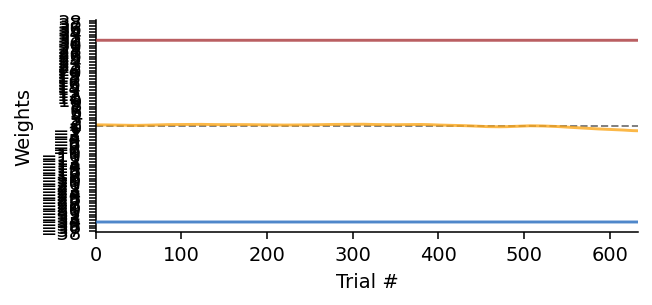

In [43]:


# Psytrack plot
fig = psy.plot_weights(wMode, weights)



In [44]:
df_v = df[(df['genotype']== 'DAT')]
df_m = df_v[df_v['stage'].isin(['training', 'bias'])]

KeyError: 'genotype'

In [45]:
def psy_track_IBL(df_m):
    """
    Run psy.hyperOpt on a DataFrame with columns
    ['choice', 'contrastLeft', 'contrastRight'].
    'choice' = -1 making a right choice
               1 making a left choice 


    Parameters
    ----------
    df_m : pandas.DataFrame
        Must contain 'choice', 'contrastLeft', 'contrastRight'.

    Returns
    -------
    hyp : a dictionary of the optimized hyperparameters
    evd : the approximate log-evidence of the optimized model
    wMode : the weight trajectories of the optimized model
    hess_info : a dictionary of sparse terms that relate to the Hessian of 
                the optimal model. By default, this also includes the posterior 
                credible intervals on the weights, under the key W_std. This behavior 
                can be altered by changing the optional argument hess_calc in hyperOpt() 
                (see function documentation for more details).
    """
    # 1) creat the DayLength list: 
    dayLength = len(df_m) #This value can be changed. It corresponds to the number of days to run the 
                         # PsyTrack fucntion until it resets. In Bias mode, you might want to set it 
                          # to the length of the bias blocks. 
    
    # 2) build the input dict
    input_dict = {
        'y': np.array([2 if c < 0 else 1 for c in df_m['choice']]),  # changing the choice value so that 1 = making a left choice and 2 = making a right choice
        'inputs': {
            's1': np.abs(df_m['contrastRight']).values.reshape(-1, 1),
            's2': np.abs(df_m['contrastLeft']).values.reshape(-1, 1)
        },
        'dayLength' : dayLength 
        }

    # 2) define your weights
    weights = {
        'bias': 1,  
        's1': 1,
        's2': 1
    }
    # total number of weights
    K = sum(weights.values())

    # 3) define your hyper‐parameters and which to optimize
    hyper = {
        'sigInit': 2**4,          # fixed init
        'sigma': [2**-6] * K,     # how the weights can evolve
        'sigDay': dayLength     # allows the weights to jump at specific time points
    }
    optList = ['sigma', 'sigDay'] # you can remove SigDay, if you don't want your weights to reset in function
                                  # of previously defined number of trials 

    # 4) call hyperOpt and return everything
    hyp, evd, wMode, hess_info = psy.hyperOpt(input_dict, hyper, weights, optList)
    return hyp, evd, wMode, hess_info


In [46]:
def psy_track_dayLength(df_m):
    """
    Run psy.hyperOpt on a DataFrame with columns
    ['choice', 'contrastLeft', 'contrastRight', 'probabilityLeft'].
    'choice' = -1 making a right choice
               1 making a left choice 

    Parameters
    ----------
    df_m : pandas.DataFrame
        Must contain 'choice', 'contrastLeft', 'contrastRight', 'probabilityLeft'.

    Returns
    -------
    hyp : a dictionary of the optimized hyperparameters
    evd : the approximate log-evidence of the optimized model
    wMode : the weight trajectories of the optimized model
    hess_info : a dictionary of sparse terms that relate to the Hessian of 
                the optimal model. By default, this also includes the posterior 
                credible intervals on the weights, under the key W_std. This behavior 
                can be altered by changing the optional argument hess_calc in hyperOpt() 
                (see function documentation for more details).
    """
    # 1) creat the DayLength list, counting the number of trials per bias state: 
    change_points = df_m['probabilityLeft'].ne(df_m['probabilityLeft'].shift())
    groups= change_points.cumsum()
    dayLength = df_m.groupby(groups).size().tolist()
    
    
    # 2) build the input dict
    input_dict = {
        'y': np.array([2 if c < 0 else 1 for c in df_m['choice']]),  # changing the choice value so that 1 = making a left choice and 2 = making a right choice
        'inputs': {
            's1': np.abs(df_m['contrastRight']).values.reshape(-1, 1),
            's2': np.abs(df_m['contrastLeft']).values.reshape(-1, 1)
        },
        'dayLength' : dayLength 
        }

    # 2) define your weights
    weights = {
        'bias': 1,  
        's1': 1,
        's2': 1
    }
    # total number of weights
    K = sum(weights.values())

    # 3) define your hyper‐parameters and which to optimize
    hyper = {
        'sigInit': 2**4,          # fixed init
        'sigma': [2**-6] * K,     # how the weights can evolve
        'sigDay': dayLength     # allows the weights to jump at specific time points
    }
    optList = ['sigma', 'sigDay'] # you can remove SigDay, if you don't want your weights to reset in function
                                  # of previously defined number of trials 

    # 4) call hyperOpt and return everything
    hyp, evd, wMode, hess_info = psy.hyperOpt(input_dict, hyper, weights, optList)
    return hyp, evd, wMode, hess_info

In [47]:
weights = {'bias': 1,  # a special key
           's1': 1,
           's2': 1
           } 
# It is often useful to have the total number of weights K in your model
K = np.sum([weights[i] for i in weights.keys()])


In [48]:
def psy_track_all_sessions(df_m):
    """
    Run psy.hyperOpt for each subject/session in df_m and concatenate all the weigth trajectories. 
    In other words, each sessions is being optimsie individually, allowing for a bigger weight jump between 
    sessions.
    
    Parameters
    ----------
    df_m : pandas.DataFrame
        Must contain ['subject','session_num','stage','choice',
                       'contrastLeft','contrastRight','probabilityLeft'].
                       'subject' = mice ID
                       'session_num'
                       'stage' = ['bias'] or ['training']
                       'choice' = -1 making a right choice, 1 making a left choice 
                       'contrastLeft' 
                       'contrastRight'
                       'probabilityLeft'
    Returns
    -------
    final_weight : pandas.DataFrame
        All sessions’ weight DataFrames concatenated.
    errors_df : pandas.DataFrame
        Sessions that failed, with error messages.
    results : dict
        Nested dicts: results['hyp'], results['evd'], results['wMode'], results['hess_info']
        keyed by (subject, session_num).
    """
    # 1) define the weights
    weights = {
        'bias': 1,
        's1'  : 1,
        's2'  : 1
    }
    K = sum(weights.values())
    
    # outputs
    all_weights     = []
    error_sessions  = []
    hyp             = {}
    evd             = {}
    wMode           = {}
    hess_info       = {}
    
    # Going through each subject and sessions at a time:
    for (subject, session_num), df_session in df_m.groupby(['subject','session_num']):
        stage = df_session['stage'].iloc[0]
        try:
            # 1) compute dayLength per stage (training vs bias)
            if stage == 'bias':
                # find run-lengths of constant probabilityLeft
                changes = df_session['probabilityLeft'].ne(df_session['probabilityLeft'].shift())
                grp     = changes.cumsum()
                dayLength = df_session.groupby(grp).size().tolist()
            else:
                dayLength = len(df_session)
            
            # 2) Create the inputs
            inp = {
                'y': np.array([2 if c < 0 else 1 for c in df_session['choice']]),   # changing the choice value so that 1 = making a left choice and 2 = making a right choice
                'inputs': {
                    's1': np.abs(df_session['contrastRight'].values).reshape(-1,1),
                    's2': np.abs(df_session['contrastLeft'].values).reshape(-1,1)
                },
                'dayLength': dayLength
            }
            
            # 3) hyper and optList
            K = sum(weights.values())
            hyper = {
                'sigInit': 2**4.,
                'sigma'  : [2**-6] * K,
                'sigDay' : dayLength
            }
            optList = ['sigma','sigDay']
            
            # 4) run psyTrack
            h, e, w, hi = psy.hyperOpt(inp, hyper, weights, optList)
            hyp[(subject, session_num)]       = h
            evd[(subject, session_num)]       = e
            wMode[(subject, session_num)]     = w
            hess_info[(subject, session_num)] = hi
            
            # 5) build session‐level weights DataFrame
            wdf = pd.DataFrame(w).T.rename(columns={0:'bias',1:'right',2:'left'})
            wdf['subject']         = subject
            wdf['session_num']     = session_num
            wdf['stage']           = stage
            wdf['probabilityLeft'] = df_session['probabilityLeft'].values
            all_weights.append(wdf)
        
        except Exception as ex:
            error_sessions.append({
                'subject': subject,
                'session_num': session_num,
                'error_type': str(ex)
            })
    
    # concatenate
    final_weight = pd.concat(all_weights, ignore_index=True) if all_weights else pd.DataFrame()
    errors_df    = pd.DataFrame(error_sessions)
    results = {
        'hyp': hyp,
        'evd': evd,
        'wMode': wMode,
        'hess_info': hess_info
    }
    return final_weight, errors_df, results

In [49]:


# run the def function: 
hyp, evd, wMode, hess_info = psy_track_dayLength(df_m)



/home/kceniabougrova/.local/lib/python3.10/site-packages/psytrack/getMAP.py:322: RuntimeWarning: invalid value encountered in logaddexp
  logli = np.sum(y * gw - np.logaddexp(0, gw))


ValueError: array must not contain infs or NaNs